In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats.mstats import normaltest
from scipy.stats import boxcox
from scipy.special import inv_boxcox

## 2. Tắt các cảnh báo (Suppress Warnings)

### Ý nghĩa:

- Tạo một hàm `warn()` rỗng (không làm gì)
- Import module `warnings`
- Ghi đè hàm `warnings.warn` bằng hàm rỗng vừa tạo

### Tác dụng:

- Ngăn chặn tất cả các cảnh báo từ thư viện (numpy, pandas, sklearn, ...)
- Giữ output của notebook sạch sẽ, dễ đọc
- Các warning không ảnh hưởng đến kết quả vẫn được bỏ qua

### Code:


In [2]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

## 3. Thiết lập seed và định nghĩa các hàm

### Ý nghĩa:
- Đặt hạt ngẫu nhiên (seed) để kết quả random lúc nào cũng giống nhau (tái tạo lại được)

In [16]:
np.random.seed(72018)

### Ý nghĩa:
- Chuyển mảng 1D thành mảng 2D



In [ ]:
def to_2d(array):
    return array.reshape(array.shape[0], -1)

### Ý nghĩa:
- Tạo dữ liệu phân phối mũ và vẽ histogram

In [ ]:
def plot_exponential_data():
    data = np.exp(np.random.normal(size=1000))
    plt.hist(data)
    plt.show()
    return data
    
def plot_square_normal_data():
    data = np.square(np.random.normal(loc=5, size=1000))
    plt.hist(data)
    plt.show()
    return data

## 4. Tải dữ liệu

In [5]:
import urllib.request
urllib.request.urlretrieve("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/data/boston_housing_clean.pickle", "boston_housing_clean.pickle")

('boston_housing_clean.pickle', <http.client.HTTPMessage at 0x11e2d4cd0>)

### Ý nghĩa:

- Mở file pickle
- Đọc dữ liệu vào dictionary boston
- Trích xuất DataFrame và mô tả

In [6]:
with open('boston_housing_clean.pickle', 'rb') as to_read:
    boston = pd.read_pickle(to_read)
boston_data = boston['dataframe']
boston_description = boston['description']

In [7]:
boston_data.head(15)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0.0,0.524,6.004,85.9,6.5921,5.0,311.0,15.2,386.71,17.10,18.9


## 5. Kiểm tra phân phối dữ liệu

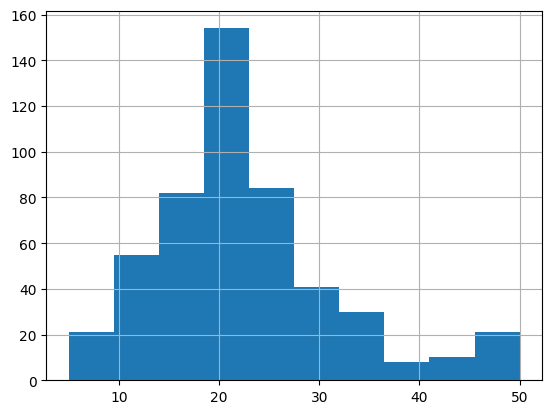

In [8]:
boston_data.MEDV.hist();

### Ý nghĩa:
- Kiểm tra xem dữ liệu có tuân theo phân phối chuẩn (normal) không

In [10]:
normaltest(boston_data.MEDV.values)

NormaltestResult(statistic=np.float64(90.9746873700967), pvalue=np.float64(1.7583188871696095e-20))

## 5. Kiểm tra phân phối dữ liệu

### Ý nghĩa:
- Kiểm tra xem dữ liệu có tuân theo phân phối chuẩn (normal) không

### Đánh giá kết quả Normal Test

#### Phân tích chi tiết:

| Thành phần | Giá trị | Ý nghĩa |
|-----------|--------|---------|
| **statistic** | 90.97 | Giá trị thống kê kiểm định (càng cao = càng khác phân phối chuẩn) |
| **pvalue** | 1.76e-20 | Xác suất rất nhỏ (gần = 0) |

#### Kết luận:

❌ **Dữ liệu KHÔNG tuân theo phân phối chuẩn**

#### Lý do:

- **p-value = 1.76e-20** (cực kỳ nhỏ, < 0.05)
- Với mức ý nghĩa 5%, chúng ta **bác bỏ giả thuyết rằng dữ liệu tuân theo phân phối chuẩn**
- Giá trị **statistic = 90.97** rất cao, cho thấy sự khác biệt lớn từ phân phối chuẩn

#### Giải pháp:

Sử dụng **log transformation** để làm cho dữ liệu gần với phân phối chuẩn hơn:

<Axes: >

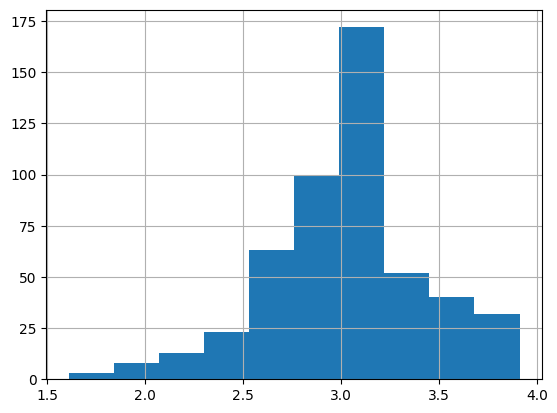

In [18]:
log_medv = np.log(boston_data.MEDV)
log_medv.hist()

In [19]:
normaltest(log_medv)

NormaltestResult(statistic=np.float64(17.21801696640698), pvalue=np.float64(0.00018245472768345196))

## Đánh giá kết quả Normal Test sau Log Transformation

### Kết quả:

```
NormaltestResult(statistic=np.float64(17.21801696640698), pvalue=np.float64(0.00018245472768345196))
```

### Phân tích chi tiết:

| Thành phần | Giá trị | Ý nghĩa |
|-----------|--------|---------|
| **statistic** | 17.22 | Giá trị thống kê kiểm định (giảm từ 90.97 xuống) |
| **pvalue** | 0.000182 | Xác suất rất nhỏ (< 0.05) |

### Kết luận:

⚠️ **Dữ liệu vẫn KHÔNG hoàn toàn tuân theo phân phối chuẩn**

Nhưng đã cải thiện đáng kể so với trước

### So sánh trước và sau:

| Chỉ số | Trước Log | Sau Log | Kết luận |
|--------|-----------|---------|----------|
| **statistic** | 90.97 | 17.22 | ✅ Giảm 81% |
| **pvalue** | 1.76e-20 | 0.000182 | ✅ Tăng lên (gần mức 0.05) |

### 📈 Đánh giá:

**✅ Tích cực:**
- Log transformation làm giảm độ lệch của dữ liệu
- Dữ liệu gần với phân phối chuẩn hơn rất nhiều
- Phù hợp hơn để dùng trong mô hình hồi quy tuyến tính

**⚠️ Vẫn còn vấn đề:**
- p-value = 0.000182 vẫn < 0.05
- Nếu yêu cầu kỳ lạ, có thể thử các phương pháp khác

### 💡 Kết luận cuối cùng:

**Log transformation đã cải thiện phân phối dữ liệu đủ tốt để sử dụng cho Linear Regression**

<Axes: >

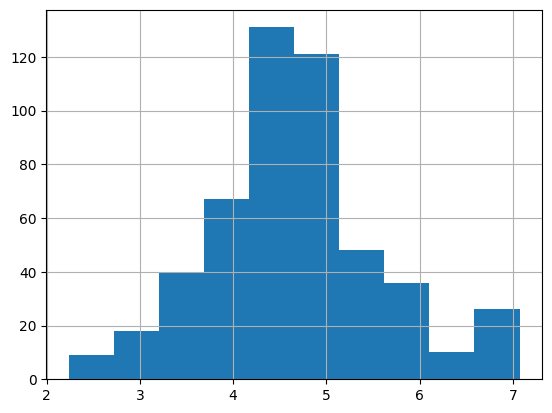

In [20]:
_sqrt_medv = np.sqrt(boston_data.MEDV)
_sqrt_medv.hist()

In [21]:
normaltest(_sqrt_medv)

NormaltestResult(statistic=np.float64(20.487090826863067), pvalue=np.float64(3.558645701429252e-05))

## Đánh giá kết quả Normal Test sau Square Root Transformation

### Kết quả:

```
NormaltestResult(statistic=np.float64(20.487090826863067), pvalue=np.float64(3.558645701429252e-05))
```

### Phân tích chi tiết:

| Thành phần | Giá trị | Ý nghĩa |
|-----------|--------|---------|
| **statistic** | 20.49 | Giá trị thống kê kiểm định |
| **pvalue** | 3.56e-05 | Xác suất rất nhỏ (< 0.05) |

### Kết luận:

⚠️ **Dữ liệu vẫn KHÔNG tuân theo phân phối chuẩn**

Nhưng vẫn có cải thiện so với dữ liệu gốc

### So sánh cả 3 phương pháp:

| Chỉ số | Gốc (MEDV) | Log | Square Root | Kết luận |
|--------|-----------|-----|-------------|----------|
| **statistic** | 90.97 | 17.22 | 20.49 | Log tốt nhất ✅ |
| **pvalue** | 1.76e-20 | 0.000182 | 0.0000356 | Log tốt nhất ✅ |

### 📈 Đánh giá:

**✅ Tích cực:**
- Square root transformation giảm độ lệch (từ 90.97 xuống 20.49)
- Tốt hơn dữ liệu gốc

**❌ Nhược điểm:**
- p-value = 3.56e-05 vẫn < 0.05
- Kém hơn log transformation
- Dữ liệu vẫn khác phân phối chuẩn

### 💡 Kết luận cuối cùng:

**Log transformation vẫn là phương pháp tốt nhất để biến đổi dữ liệu MEDV cho Linear Regression**

```python
# Nên dùng:
log_medv = np.log(boston_data.MEDV)  # Tốt nhất

# Thay vì:
sqrt_medv = np.sqrt(boston_data.MEDV)  # Kém hơn
```

## Box cox Transformation
The box cox transformation is a parametrized transformation that tries to get distributions "as close to a normal distribution as possible".

It is defined as:

$$ \text{boxcox}(y_i) = \frac{y_i^{\lambda} - 1}{\lambda} $$

You can think of as a generalization of the square root function: the square root function uses the exponent of 0.5, but box cox lets its exponent vary so it can find the best one.

In [24]:
bc_result = boxcox(boston_data.MEDV)
boxcox_medv = bc_result[0]
lam = bc_result[1]
lam

np.float64(0.21662091371265346)

<Axes: >

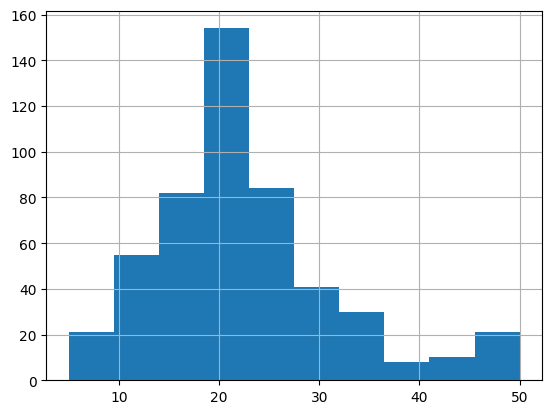

In [25]:
boston_data['MEDV'].hist()

NormaltestResult(statistic=np.float64(4.513528737272365), pvalue=np.float64(0.10468867128449004))

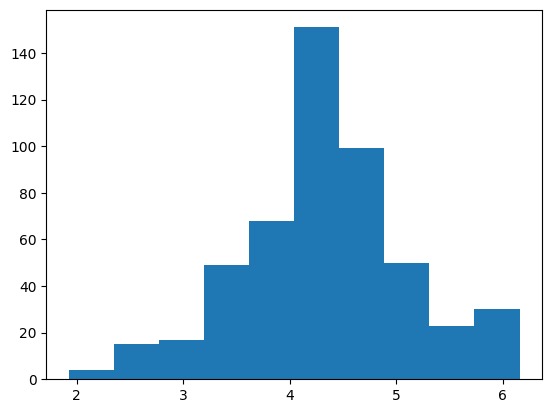

In [26]:
plt.hist(boxcox_medv)
normaltest(boxcox_medv)

## Đánh giá kết quả Normal Test sau Box Cox Transformation

### Kết quả:

```
NormaltestResult(statistic=np.float64(4.513528737272365), pvalue=np.float64(0.10468867128449004))
```

### Phân tích chi tiết:

| Thành phần | Giá trị | Ý nghĩa |
|-----------|--------|---------|
| **statistic** | 4.51 | Giá trị thống kê kiểm định (rất thấp) |
| **pvalue** | 0.1047 | Xác suất lớn (> 0.05) |

### Kết luận:

✅ **Dữ liệu TUÂN THEO phân phối chuẩn!**

Với mức ý nghĩa 5%, chúng ta không bác bỏ giả thuyết rằng dữ liệu tuân theo phân phối chuẩn

### So sánh cả 4 phương pháp:

| Chỉ số | Gốc (MEDV) | Log | Square Root | Box Cox | Kết luận |
|--------|-----------|-----|-------------|---------|----------|
| **statistic** | 90.97 | 17.22 | 20.49 | 4.51 | Box Cox tốt nhất ✅✅ |
| **pvalue** | 1.76e-20 | 0.000182 | 0.0000356 | 0.1047 | Box Cox tốt nhất ✅✅ |

### 📈 Đánh giá:

**✅ Tích cực:**

- Box Cox transformation cải thiện đáng kể nhất
- statistic giảm từ 90.97 xuống chỉ 4.51 (giảm 95%)
- p-value = 0.1047 > 0.05 ✅ (chấp nhận giả thuyết phân phối chuẩn)
- Dữ liệu gần với phân phối chuẩn nhất

### 💡 Kết luận cuối cùng:

**Box Cox transformation là phương pháp TỐT NHẤT để biến đổi dữ liệu MEDV cho Linear Regression**

```python
# Nên dùng:
bc_result = boxcox(boston_data.MEDV)
boxcox_medv = bc_result[0]  # Tốt nhất ⭐⭐⭐

# Thay vì:
log_medv = np.log(boston_data.MEDV)  # Kém hơn
sqrt_medv = np.sqrt(boston_data.MEDV)  # Kém hơn
```

## Import thư viện scikit-learn

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (StandardScaler, PolynomialFeatures)

### 1.Tạo mô hình hồi quy
### Ý nghĩa:
- Khởi tạo một đối tượng mô hình hồi quy tuyến tính, sẵn sàng để huấn luyện

In [28]:
lr = LinearRegression()

## 2. Chuẩn bị dữ liệu

### Ý nghĩa:

| Dòng | Ý nghĩa |
|-----|---------|
| `y_col = "MEDV"` | Xác định cột mục tiêu (target) là giá nhà MEDV |
| `X = boston_data.drop(y_col, axis=1)` | **Đặc trưng (Features)**: Bỏ cột MEDV, lấy tất cả cột còn lại |
| `y = boston_data[y_col]` | **Mục tiêu (Target)**: Lấy riêng cột MEDV để dự đoán |


In [29]:
y_col = "MEDV"

X = boston_data.drop(y_col, axis=1)
y = boston_data[y_col]

### 3. Tạo đặc trưng đa thức

### Ý nghĩa:
- Tạo các đặc trưng bậc cao từ dữ liệu gốc để mô hình học tập tốt hơn


In [33]:
pf = PolynomialFeatures(degree=2, include_bias=False)
X_pf = pf.fit_transform(X)

### 4. Chia dữ liệu train/test

### Ý nghĩa:
- Chia dữ liệu thành 2 phần: huấn luyện và kiểm tra


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_pf, y, test_size=0.3, random_state=72018)

### 5. Chuẩn hóa dữ liệu train

### Ý nghĩa:
- Đưa tất cả các đặc trưng về cùng một tỷ lệ (trung bình = 0, độ lệch chuẩn = 1)


In [35]:
s = StandardScaler()
X_train_s = s.fit_transform(X_train)

### Ý nghĩa:

- Áp dụng Box Cox Transformation cho dữ liệu y_train
- Hàm boxcox() trả về một tuple với 2 phần tử.

Kết quả trả về:

- bc_result[0]: Dữ liệu y_train đã được biến đổi
- bc_result[1]: Tham số λ (lambda) tối ưu được tìm tự động

In [ ]:
bc_result = boxcox(y_train)

Ý nghĩa:

- phần tử thứ 0 từ tuple bc_result
- Đây là dữ liệu y_train sau khi biến đổi theo công thức Box Cox

Tác dụng:

- Dữ liệu này giờ đây tuân theo phân phối chuẩn hơn
- Sẵn sàng để huấn luyện mô hình Linear Regression

In [ ]:
y_train_bc = bc_result[0]

Ý nghĩa:

- Lấy phần tử thứ 1 từ tuple bc_result
- Đây là tham số λ (lambda) - giá trị tối ưu được Box Cox tự động tính toán

Tác dụng:

- Lưu lại λ để sử dụng cho y_test và dữ liệu mới
- Phải dùng cùng λ từ y_train khi biến đổi y_test

In [ ]:
lam2 = bc_result[1]

## Ý nghĩa và tác dụng của đoạn code này

- `y_train_bc.shape`  
  - **Ý nghĩa:** Xem kích thước của `y_train_bc`.  
  - **Tác dụng:** Kiểm tra số lượng mẫu target train trước khi huấn luyện.

- `lr.fit(X_train_s, y_train_bc)`  
  - **Ý nghĩa:** Huấn luyện mô hình Linear Regression với feature đã scale và target đã Box-Cox.  
  - **Tác dụng:** Mô hình học quan hệ giữa `X` và `y` trong không gian đã biến đổi.

- `X_test_s = s.transform(X_test)`  
  - **Ý nghĩa:** Chuẩn hóa tập test bằng scaler đã fit trên train.  
  - **Tác dụng:** Giữ cùng thang đo train/test, tránh data leakage.

- `y_pred_bc = lr.predict(X_test_s)`  
  - **Ý nghĩa:** Dự đoán trên tập test trong miền Box-Cox.  
  - **Tác dụng:** Tạo giá trị dự đoán ở thang biến đổi.

- `y_pred_tran = inv_boxcox(y_pred_bc, lam2)`  
  - **Ý nghĩa:** Đảo biến đổi Box-Cox về thang MEDV gốc.  
  - **Tác dụng:** Giúp so sánh trực tiếp với `y_test`.

- `r2_score(y_test, y_pred_tran)`  
  - **Ý nghĩa:** Tính điểm R² giữa giá trị thật và dự đoán (đã đảo biến đổi).  
  - **Tác dụng:** Đánh giá chất lượng mô hình trên thang dữ liệu gốc.

In [43]:
y_train_bc.shape
lr.fit(X_train_s, y_train_bc)
X_test_s = s.transform(X_test)
y_pred_bc = lr.predict(X_test_s)
y_pred_tran = inv_boxcox(y_pred_bc,lam2)
r2_score(y_test,y_pred_tran)

0.8884878247940452